# US Honey case study

**Note:**
- In this experiment, we will perform several operations on a CSV file using the NumPy, Pandas, Matplotlib, and Seaborn libraries.
- Our main focus will be on key operations that are commonly used in these libraries.
- The following operations will be conducted on the CSV file:
  - Importing the necessary libraries.
  - Loading the dataset into the experiment.
  - Understanding the data in the file.
  - Performing data cleaning and visualization operations.
  - Preparing the data for further processes in the Data Science Life Cycle.

**Experment Link** --> https://colab.research.google.com/drive/1pRctndAkRiH86oyAQWq48lEgLFgyYG3U?usp=sharing

**Data set Link** --> https://drive.google.com/file/d/18bt5HvPk1vfCNnd0iUFNai6AVS3pPD_f/view?usp=sharing

In [1]:
# Importing the required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the data_set.
df = pd.read_csv("/content/US_honey_dataset.csv")

In [3]:
# Understanding the data_set.
df.head()

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1115 non-null   int64  
 1   state                1115 non-null   object 
 2   colonies_number      1115 non-null   int64  
 3   yield_per_colony     1115 non-null   int64  
 4   production           1115 non-null   int64  
 5   stocks               1115 non-null   int64  
 6   average_price        1115 non-null   float64
 7   value_of_production  1115 non-null   int64  
 8   year                 1115 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 78.5+ KB


- Observing the data set for how many types of data are contained in the CSV_file.

- By this, we understand the dataset's composition and the different data types present in the file.

In [5]:
df.shape

(1115, 9)

-  We are now going to perform some data cleaning operations on the file.

In [6]:
# checking for null values
df.isnull().sum()

,0
Unnamed: 0,0
state,0
colonies_number,0
yield_per_colony,0
production,0
stocks,0
average_price,0
value_of_production,0
year,0


In [7]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [8]:
# Checking how many states contribute to honey production and their counts.
df['state'].value_counts()

,count
state,
Alabama,27
Arizona,27
Arkansas,27
California,27
Colorado,27
Florida,27
Georgia,27
Hawaii,27
Idaho,27


In [9]:
df.shape

(1115, 9)

- we are dropen unwanted columns.

In [10]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [11]:
df.dtypes

,0
state,object
colonies_number,int64
yield_per_colony,int64
production,int64
stocks,int64
average_price,float64
value_of_production,int64
year,int64


/tmp/ipykernel_862/2338504973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state',y='production',data=df,palette='dark')


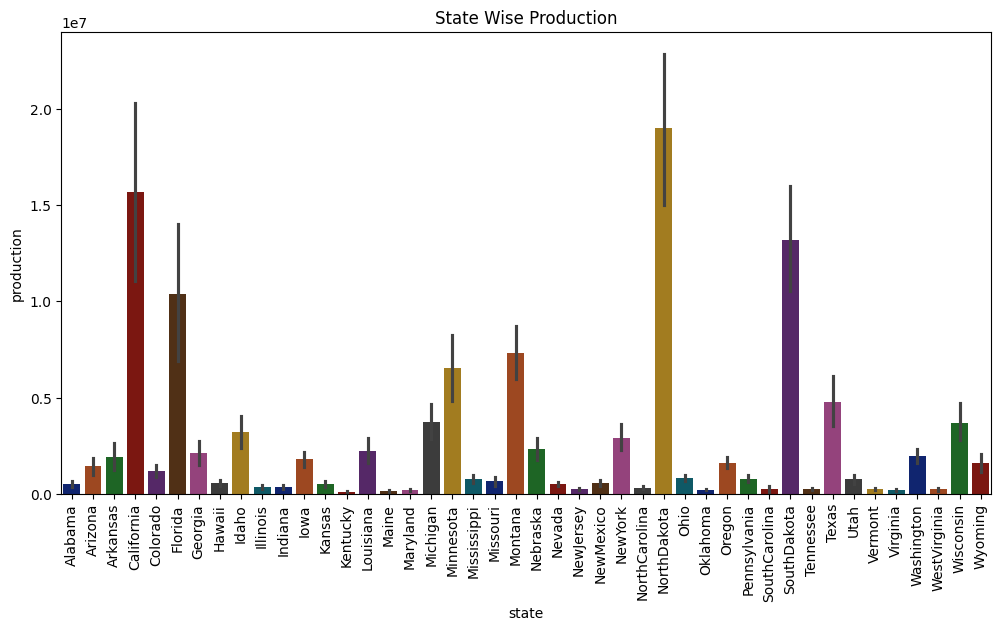

In [12]:
# State Wise Prediction
plt.figure(figsize=(12,6))
sns.barplot(x='state',y='production',data=df,palette='dark')
plt.title('State Wise Production')
plt.xlabel('state')
plt.ylabel('production')
plt.xticks(rotation=90)
plt.show()

1. Which are the top 5 Honey producing states in the US ?

In [13]:
x = df.groupby('state')['production'].sum().reset_index()

In [14]:
x

,state,production
0,Alabama,14467000
1,Arizona,38844000
2,Arkansas,51846000
3,California,423876000
4,Colorado,32660000
5,Florida,280934000
6,Georgia,57426000
7,Hawaii,15420000
8,Idaho,87188000
9,Illinois,9864000


In [15]:
top5_states = x.sort_values(by='production',ascending=False).head()

In [16]:
top5_states

,state,production
28,NorthDakota,513742000
3,California,423876000
34,SouthDakota,355726000
5,Florida,280934000
21,Montana,197173000


**Insghts**

 - We are grouping the 'state' and 'production' columns by using the "groupby()" function.
 - After i am using the "sort_values()" function to sort the values.
 - we got top-5 states in production, shown in the above dataframe.

2. Which states are least 5 contributing to honey production for the last 27 years?

In [17]:
least5_states = x.sort_values(by='production',ascending=False).tail()

In [18]:
least5_states

,state,production
15,Maine,4762000
13,Kentucky,3224000
33,SouthCarolina,2823000
30,Oklahoma,2055000
16,Maryland,1975000


**Insghts**

- We are grouping the 'state' and 'production' columns by using the "groupby()" function.
- After i am using the "sort_values()" function to sort the values.
- we got least-5 states in production, shown in the above dataframe.

3. What is the Change in mean Average price of Honey from 1995 to 2021?

In [19]:
y = df.groupby('year')['average_price'].mean()

In [20]:
y

,average_price
year,
1995,74.840909
1996,99.568182
1997,91.325581
1998,83.720930
1999,80.325581
2000,79.023256
2001,88.465116
2002,133.204545
2003,151.068182


In [21]:
z = y.loc[1995] - y.loc[2021]

In [22]:
z

np.float64(71.5066590909091)

**Insights**
- We are grouping the 'year' and 'average_price' columns by using the "groupby()" function.
- After grouping to finding the mean of 'average_price' we us the "mean()" function.

4. Which was the year when production of Honey in wholeUS was the highest?

In [23]:
Highest_production = df.groupby('year')['production'].sum().reset_index()

In [24]:
Highest_production.sort_values(by='production',ascending=False).head()

,year,production
5,2000,220320000
3,1998,219321000
0,1995,210272000
4,1999,204585000
1,1996,197995000


**Insights**

- We are grouping the 'year' and 'production' columns using the "groupby()" function.
- After that, I use the "sort_values()" function to arrange the values in order.
- The dataframe above shows which year had the highest production.

4. Which states have the highest no. of colonies in the year 2000?



In [25]:
a =df[df['year'] == 2000]
b =a.groupby('state')['colonies_number'].sum().reset_index()
c = b.sort_values(by='colonies_number',ascending=False)

In [26]:
b

,state,colonies_number
0,Alabama,16000
1,Arizona,40000
2,Arkansas,55000
3,California,440000
4,Colorado,29000
5,Florida,232000
6,Georgia,55000
7,Hawaii,7000
8,Idaho,100000
9,Illinois,8000


In [27]:
c.head()

,state,colonies_number
3,California,440000
28,NorthDakota,290000
33,SouthDakota,235000
5,Florida,232000
18,Minnesota,150000


**Insights**

- We are separate data where the "year = 2000" as per the question.
- We are grouping the 'state' and 'colonies_number' columns using the "groupby()" function.
- After that, I use the "sort_values()" function to arrange the values in order.
- The dataframe above shows which 'colonies_number' had the highest production.